## Desarrollo tarea HW Sesión 5

Felipe López Vergara

## 1. Fundamentos Teóricos: Estacionariedad, Persistencia y Momentos en GARCH(1,1)

Considere el modelo GARCH(1,1):

\begin{equation*}
\begin{aligned}
r_t &= \mu + \varepsilon_t \\
\varepsilon_t &= \sigma_t z_t,\quad z_t \overset{\text{iid}}{\sim} \mathcal{N}(0,1) \\
\sigma_t^2 &= \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2
\end{aligned}
\end{equation*}

con $\omega > 0$ y $\alpha,\beta \ge 0$.

### 1.1 Estacionariedad en Covarianza

**(a)** Muestre que, escribiendo $\sigma_t^2$ como un proceso ARMA(1,1) en $\epsilon_t^2$ (representación ARCH($\infty$)), la condición necesaria y suficiente para que el proceso sea débilmente estacionario es $\alpha+\beta<1$.


**Respuesta**

### Describir $(\varepsilon_t^2)$

Como

$[\varepsilon_t = \sigma_t z_t,]$

entonces

$[\varepsilon_t^2 = \sigma_t^2 z_t^2.]$

Definimos $[u_t = \sigma_t^2\left(z_t^2 - 1\right).]$

Como

$[E(z_t^2)=1,]$

se tiene

$[E\!\left(u_t \mid \mathcal{F}_{t-1}\right)=0,]$

por lo que \(u_t\) es un **ruido blanco de diferencia de martingala**.

Luego,

$[\begin{aligned}\varepsilon_t^2&= \sigma_t^2 + \sigma_t^2(z_t^2-1) \\&= \sigma_t^2 + u_t.\end{aligned}]$

Es decir,

$[\sigma_t^2 = \varepsilon_t^2 - u_t.]$

### Sustituir en la ecuación GARCH
La ecuación original del modelo GARCH(1,1) es

$[\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2.]$

Como

$[\sigma_{t-1}^2 = \varepsilon_{t-1}^2 - u_{t-1},]$

al sustituir se obtiene

$[\begin{aligned}\sigma_t^2&= \omega + \alpha \varepsilon_{t-1}^2+ \beta\left(\varepsilon_{t-1}^2 - u_{t-1}\right) \\&= \omega + (\alpha+\beta)\varepsilon_{t-1}^2- \beta u_{t-1}.\end{aligned}]$

Finalmente, como

$[\varepsilon_t^2 = \sigma_t^2 + u_t,]$

se concluye que

$[\begin{aligned}\varepsilon_t^2&= \omega + (\alpha+\beta)\varepsilon_{t-1}^2- \beta u_{t-1} + u_t \\&= \omega + (\alpha+\beta)\varepsilon_{t-1}^2+ u_t - \beta u_{t-1}.\end{aligned}]$

Esta es exactamente la representación de un modelo **ARMA(1,1)** para $(\varepsilon_t^2)$, con

- **Parte autorregresiva (AR(1))**:
  $[\phi = \alpha + \beta.]$

- **Parte de medias móviles (MA(1))**:
  $[\theta = -\beta.]$

### Condición de estacionariedad

En un proceso AR(1)

$[X_t = \phi X_{t-1} + e_t,]$

el cual es estacionario si y solo si

$[|\phi| < 1.]$

En la representación ARMA(1,1) obtenida para $(\varepsilon_t^2)$, el coeficiente autorregresivo es

$[\phi = \alpha + \beta.]$

Como, por definición del modelo GARCH(1,1),

$[\alpha \ge 0, \qquad \beta \ge 0,]$

la condición de estacionariedad se reduce a

$[\alpha + \beta < 1.]$

Por lo tanto, la condición necesaria y suficiente para que un proceso GARCH(1,1) sea débilmente estacionario (es decir, tenga una varianza incondicional constante y finita) es

$[\boxed{\alpha + \beta < 1.}]$

**(b)** Bajo dicha condición, derive la varianza incondicional:

$[\sigma^2 = \mathbb{E}[\sigma_t^2]= \frac{\omega}{1-\alpha-\beta}.]$

**Respuesta**

Queremos calcular la varianza incondicional del proceso,

$[\sigma^2 = \mathbb{E}[\varepsilon_t^2].]$

Partimos de la ecuación del modelo GARCH(1,1):

$[\sigma_t^2= \omega + \alpha \varepsilon_{t-1}^2+ \beta \sigma_{t-1}^2.]$

Tomando esperanza en ambos lados de la ecuación se obtiene

$[\mathbb{E}[\sigma_t^2]= \omega+ \alpha \mathbb{E}[\varepsilon_{t-1}^2]+ \beta \mathbb{E}[\sigma_{t-1}^2].]$

Bajo la condición de estacionariedad (\(\alpha+\beta<1\)),

$[\mathbb{E}[\sigma_t^2]=\mathbb{E}[\sigma_{t-1}^2]=\mathbb{E}[\varepsilon_t^2]=\sigma^2.]$

Por lo tanto,

$[\sigma^2= \omega + \alpha\sigma^2 + \beta\sigma^2.]$

Agrupando los términos en \(\sigma^2\),

$[\sigma^2(1-\alpha-\beta)=\omega.]$

Finalmente, despejando $(\sigma^2)$,

$[boxed{\sigma^2=\frac{\omega}{1-\alpha-\beta}}.]$

Esta es la **varianza incondicional** del proceso GARCH(1,1), la cual existe siempre que se cumpla la condición de estacionariedad

$[\alpha+\beta<1.]$

**(c)** ¿Qué ocurre con $\sigma^2$ cuando $\alpha+\beta -> 1$? Interprete este límite en términos del modelo `IGARCH` (Integrated GARCH).

**Respuesta**

En el cuadro anterior se obtuvo que la varianza incondicional del proceso GARCH(1,1) es

$[\sigma^2=\frac{\omega}{1-\alpha-\beta}.]$

Si

$[\alpha+\beta \rightarrow 1,]$

entonces

$[1-\alpha-\beta \rightarrow 0^{+},]$

por lo que

$[\sigma^2=\frac{\omega}{1-\alpha-\beta}\longrightarrow \infty.]$

Es decir, la **varianza incondicional deja de existir** (se vuelve infinita).

#### Interpretación: modelo IGARCH

Cuando

$[\alpha+\beta=1,]$

el modelo recibe el nombre de **Integrated GARCH (IGARCH)**.

En este caso:

-No existe una varianza incondicional finita;
-Los choques de volatilidad son permanentes;
-La volatilidad presenta persistencia infinita: un shock no desaparece con el tiempo;
-La varianza condicional depende fuertemente de toda la historia pasada y no converge a un nivel de largo plazo.

Por ello, un IGARCH describe mercados donde la volatilidad es altamente persistente y tarda indefinidamente en regresar a un valor de equilibrio.

## 1.2 Persistencia y Vida Media de un Shock

Un shock de volatilidad en $t$ decae geométricamente a tasa $(\alpha+\beta)$.

**(a)** Muestre que $[\mathbb{E}\!\left[\sigma_{t+h}^2-\sigma^2 \,\middle|\, \mathcal{F}_t\right]=(\alpha+\beta)^h\left(\sigma_{t+1}^2-\sigma^2\right).]$

**Respuesta**

### A partir del modelo GARCH(1,1)

La ecuación del modelo es

$[\sigma_t^2=\omega+\alpha\varepsilon_{t-1}^2+\beta\sigma_{t-1}^2.]$

Además,

$[\mathbb{E}\!\left[\varepsilon_t^2 \mid \mathcal{F}_{t-1}\right]=\sigma_t^2.]$

Por lo tanto,

$[\mathbb{E}\!\left[\sigma_{t+1}^2 \mid \mathcal{F}_t\right]=\omega+\alpha\,\mathbb{E}\!\left[\varepsilon_t^2 \mid \mathcal{F}_t\right]+\beta\sigma_t^2.]$

Como

$[\mathbb{E}\!\left[\varepsilon_t^2 \mid \mathcal{F}_t\right]=\sigma_t^2,]$

se obtiene

$[\mathbb{E}\!\left[\sigma_{t+1}^2 \mid \mathcal{F}_t\right]=\omega+(\alpha+\beta)\sigma_t^2.]$

#### Restar la varianza de largo plazo

La varianza incondicional es

$[\sigma^2=\frac{\omega}{1-\alpha-\beta},]$

lo que implica

$[\omega=(1-\alpha-\beta)\sigma^2.]$

Sustituyendo en la expresión anterior,

$[\mathbb{E}\!\left[\sigma_{t+1}^2 \mid \mathcal{F}_t\right]=(1-\alpha-\beta)\sigma^2+(\alpha+\beta)\sigma_t^2.]$

Restando $(\sigma^2)$ en ambos lados,

$[\begin{aligned}\mathbb{E}\!\left[\sigma_{t+1}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]&=(\alpha+\beta)(\sigma_t^2-\sigma^2).\end{aligned}]$

#### Aplicar recursión

Un paso más adelante,

$[\mathbb{E}\!\left[\sigma_{t+2}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]=(\alpha+\beta)\mathbb{E}\!\left[\sigma_{t+1}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right].]$

Sustituyendo el resultado anterior,

$[\mathbb{E}\!\left[\sigma_{t+2}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]=(\alpha+\beta)^2(\sigma_t^2-\sigma^2).]$

Repitiendo el argumento por inducción para un horizonte $(h)$,

$[\boxed{\mathbb{E}\!\left[\sigma_{t+h}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]=(\alpha+\beta)^h(\sigma_t^2-\sigma^2).}]$

Esta expresión demuestra que un **shock de volatilidad** se desvanece geométricamente a una tasa igual a $(\alpha+\beta)$. En consecuencia, cuanto más cercano sea $(\alpha+\beta)$ a 1, mayor será la persistencia de la volatilidad y más lentamente desaparecerá el efecto del shock.

**(b)** Defina la **vida media** (*half-life*) de un shock como el número de períodos $(h^{*})$ necesario para que la desviación de la varianza condicional respecto de su nivel de largo plazo, $(\sigma^2)$, se reduzca a la mitad. Muestre que

$[h^{*}=\frac{\ln(0.5)}{\ln(\alpha+\beta)}.]$

**Respuesta**

La **vida media** (*half-life*) de un shock se define como el número de períodos necesarios para que el efecto de dicho shock sobre la varianza condicional se reduzca a la mitad.

Del ejercicio anterior,

$[(\alpha+\beta)^h(\sigma_t^2-\sigma^2)]$

representa el efecto remanente del shock después de $(h)$ períodos.

Por definición de vida media,

$[(\alpha+\beta)^{h^{*}}=\frac{1}{2}.]$

Tomando logaritmos naturales en ambos lados,

$[h^{*}\ln(\alpha+\beta)=\ln(0.5).]$

Despejando \(h^{*}\),

$[\boxed{h^{*}=\frac{\ln(0.5)}{\ln(\alpha+\beta)}}.]$

Como

$[0<\alpha+\beta<1,]$

se tiene que

$[\ln(\alpha+\beta)<0\quad\text{y}\quad\ln(0.5)<0,]$

por lo que

$[h^{*}>0.]

En consecuencia, cuanto más cercano sea $(\alpha+\beta)$ a 1, mayor será la vida media del shock y más lentamente desaparecerá el efecto de una perturbación sobre la volatilidad.

**(c)** Calcula $h^{*}$ para $(\alpha,\beta) = (0,05, 0,90)$, $(0,10, 0,85)$ y $(0,02, 0,97)$. ¿Qué combinación implica volatilidad más persistente?

La vida media de un shock está dada por

$h^{*}=\frac{\ln(0.5)}{\ln(\alpha+\beta)}.$

El valor del ln de 0,5 es $[\ln(0.5)=-0.693147.$

#### Primer caso: $((\alpha,\beta)=(0.05,\,0.90))$

En este caso,

$\alpha+\beta=0.95.$

Por lo tanto,

$\begin{aligned}h^{*}&=\frac{\ln(0.5)}{\ln(0.95)} \\&=\frac{-0.693147}{-0.051293} \\&\approx 13.52.\end{aligned}$

Así,

$\boxed{h^{*}\approx 13.5 \text{ períodos}.}$

#### Segundo caso: $((\alpha,\beta)=(0.10,\,0.85))$

Nuevamente,

$\alpha+\beta=0.95,$

por lo que

$boxed{h^{*}\approx 13.5 \text{ períodos}.}$

Aunque los parámetros individuales cambian, la persistencia depende únicamente de la suma $\alpha+\beta$.

#### Tercer caso: $(\alpha,\beta)=(0.02,\,0.97)$

En este caso,

$\alpha+\beta=0.99.

Entonces,

$\begin{aligned}h^{*}&=\frac{\ln(0.5)}{\ln(0.99)} \\&=\frac{-0.693147}{-0.010050} \\&\approx 68.97.\end{aligned}$

Por lo tanto,

$\boxed{h^{*}\approx 69 \text{ períodos}.}$

### Interpretación

| $(\alpha,\beta)$ | $(\alpha+\beta)$ | Vida media |
|:------------------:|:----------------:|:----------:|
| \((0.05,\;0.90)\) | 0.95 | 13.5 períodos |
| \((0.10,\;0.85)\) | 0.95 | 13.5 períodos |
| \((0.02,\;0.97)\) | 0.99 | 69 períodos |

Se observa que:

- Los dos primeros modelos presentan exactamente la misma persistencia, ya que comparten el mismo valor de \(\alpha+\beta=0.95\). En consecuencia, ambos tienen una vida media de aproximadamente **13.5 períodos**.
- El tercer modelo presenta una persistencia considerablemente mayor. Al tener \(\alpha+\beta=0.99\), los efectos de un shock sobre la volatilidad se disipan muy lentamente, requiriendo aproximadamente **69 períodos** para reducirse a la mitad.
- Este comportamiento es característico de modelos cercanos a un **IGARCH**, donde la volatilidad exhibe una elevada persistencia y los choques tienen efectos de muy larga duración.

### 1.3 Momento de Cuarto Orden y Curtosis

Asumiendo $z_t\sim\mathcal{N}(0,1)$ y $3\alpha^2+2\alpha\beta+\beta^2<1$ (condición para que exista el cuarto momento incondicional):

**(a)** Muestre que la curtosis incondicional de $\epsilon_t$ es:
$$\kappa=\frac{3\left[1-(\alpha+\beta)^2\right]}{1-(\alpha+\beta)^2-2\alpha^2}.$$

**Respuesta**

#### Definición de curtosis

La curtosis incondicional es

$[\kappa=\frac{E[\varepsilon_t^4]}{\left(E[\varepsilon_t^2]\right)^2}.]$

Como

$[\varepsilon_t=\sigma_t z_t,]$

y $(z_t \sim N(0,1))$,

$[E[z_t^4]=3.]$

Por independencia entre \(z_t\) y \(\sigma_t\),

$[E[\varepsilon_t^4]= E[\sigma_t^4]E[z_t^4]= 3E[\sigma_t^4].]$

Por tanto,

$[\boxed{\kappa=3\frac{E[\sigma_t^4]}{\sigma^4}}]$

donde

$[\sigma^2=E[\sigma_t^2]=\frac{\omega}{1-\alpha-\beta}.]$

#### Elevar al cuadrado la ecuación GARCH

El modelo es

$[\sigma_t^2=\omega+\alpha\varepsilon_{t-1}^2+\beta\sigma_{t-1}^2.]$

Elevando al cuadrado,

$[\sigma_t^4=\left(\omega+\alpha\varepsilon_{t-1}^2+\beta\sigma_{t-1}^2\right)^2.]$

Expandiendo,

$[\begin{aligned}\sigma_t^4=&\ \omega^2+\alpha^2\varepsilon_{t-1}^4+\beta^2\sigma_{t-1}^4 \\&+2\omega\alpha\varepsilon_{t-1}^2+2\omega\beta\sigma_{t-1}^2+2\alpha\beta\varepsilon_{t-1}^2\sigma_{t-1}^2.\end{aligned}]$

#### Tomar esperanza

Sea

$[M_4=E[\sigma_t^4].]$

Además,

$[E[\varepsilon_t^2]=\sigma^2,\qquad E[\varepsilon_t^4]=3M_4,]$
y

$[E[\varepsilon_t^2\sigma_t^2]=E[\sigma_t^4 z_t^2]=M_4.]$

Sustituyendo,

$[\begin{aligned}M_4=&\ \omega^2+3\alpha^2 M_4+\beta^2 M_4 \\&+2\omega(\alpha+\beta)\sigma^2+2\alpha\beta M_4.\end{aligned}]$

Agrupando,

$[M_4\left[1-3\alpha^2-2\alpha\beta-\beta^2\right]=\omega^2+2\omega(\alpha+\beta)\sigma^2.]$

#### Simplificar

Como

$[\omega=(1-\alpha-\beta)\sigma^2,]$

se obtiene

$[\omega^2+2\omega(\alpha+\beta)\sigma^2=(1-\alpha-\beta)(1+\alpha+\beta)\sigma^4.]$

Pero

$[(1-\alpha-\beta)(1+\alpha+\beta)=1-(\alpha+\beta)^2.]$

Entonces

$[M_4=\frac{1-(\alpha+\beta)^2}{1-3\alpha^2-2\alpha\beta-\beta^2}\sigma^4.]$

Como

$[3\alpha^2+2\alpha\beta+\beta^2=(\alpha+\beta)^2+2\alpha^2,]$

el denominador queda

$[1-(\alpha+\beta)^2-2\alpha^2.]$

Finalmente,

$[boxed{\kappa=\frac{3\left[1-(\alpha+\beta)^2\right]}{1-(\alpha+\beta)^2-2\alpha^2}.}]$


**(b)** Muestre que $\kappa > 3$ siempre que $\alpha>0$, es decir, que el modelo GARCH(1,1) con innovaciones normales genera **exceso de curtosis** incondicional (leptocurtosis) aunque $z_t$ sea gaussiano. Relacione este resultado con los hechos estilizados vistos en clases.

**Respuesta**

Escribimos

$[\kappa=3\frac{A}{A-2\alpha^2}]$

donde

$[A=1-(\alpha+\beta)^2.]$

Como existe el cuarto momento,

$[A-2\alpha^2>0.]$

Además,

$[A > A-2\alpha^2,]$

por lo que

$[\frac{A}{A-2\alpha^2}>1.]$

Multiplicando por 3,

$[boxed{\kappa>3.}]$

#### Interpretación

La distribución normal tiene

$[\kappa=3.]$

En cambio, el modelo GARCH produce

$[\kappa>3,]$

incluso cuando $(z_t \sim N(0,1))$. Esto ocurre porque la volatilidad es estocástica, generando colas más pesadas (leptocurtosis).

**(c)** Verifique la condición de existencia del cuarto momento para los tres pares $(\alpha,\beta)$ del punto 1.2(c). ¿Existe algún caso en que la curtosis no esté definida?

**Respuesta**

La condición es

$[boxed{3\alpha^2+2\alpha\beta+\beta^2<1.}]$

#### Caso 1

$[(\alpha,\beta)=(0.05,0.90)]$

$[3(0.05)^2 + 2(0.05)(0.90) + (0.90)^2= 0.9075 < 1.]$

**Existe el cuarto momento.**

#### Caso 2

$[(\alpha,\beta)=(0.10,0.85)]$

$[0.03 + 0.17 + 0.7225 = 0.9225 < 1.]$

**Existe el cuarto momento.**

#### Caso 3

$[(\alpha,\beta)=(0.02,0.97)]$

$[0.0012 + 0.0388 + 0.9409 = 0.9809 < 1.]$

**También existe el cuarto momento.**


### Conclusión

| $(\alpha,\beta)$ | $(3\alpha^2+2\alpha\beta+\beta^2)$ | ¿Existe $(E[\varepsilon_t^4])$? |
|--------------------|------------------------------------:|:------------------------------:|
| (0.05, 0.90)       | 0.9075                             | Sí |
| (0.10, 0.85)       | 0.9225                             | Sí |
| (0.02, 0.97)       | 0.9809                             | Sí |

Los tres modelos cumplen la condición $[3\alpha^2+2\alpha\beta+\beta^2<1]$ Por lo que el cuarto momento está bien definido. Sin embargo, el tercer caso está muy cercano al límite, lo que implica alta persistencia de volatilidad y colas pesadas.

## 2. Simulación de Modelos de Volatilidad

Simule 3.000 observaciones ($r_t$) con $\mu=0$ para cada uno de los siguientes procesos, descartando las primeras 500 observaciones como *burn-in*:

In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# Modelo ARCH(1)

def simulate_arch(T, omega, alpha, mu=0, burn=500, seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    # Varianza inicial
    sigma2[0] = omega/(1-alpha)

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        sigma2[t] = omega + alpha*eps[t-1]**2

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

In [34]:
#Modelo ARCH (1)
r_arch, sigma_arch = simulate_arch(
    T=3000,
    omega=0.05,
    alpha=0.85
)
print(r_arch)

[ 0.16971387  0.01900598 -0.05953741 ...  0.28259539  0.29730076
 -0.06058222]


In [35]:
# Modelo GARCH (1,1)
def simulate_garch(T, omega, alpha, beta,
                   mu=0, burn=500, seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    sigma2[0] = omega/(1-alpha-beta)

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        sigma2[t] = (omega
                     + alpha*eps[t-1]**2
                     + beta*sigma2[t-1])

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

# GARCH baja persistencia
r_garch1, sigma_garch1 = simulate_garch(
    T=3000,
    omega=0.05,
    alpha=0.05,
    beta=0.60
)

# GARCH alta persistencia
r_garch2, sigma_garch2 = simulate_garch(
    T=3000,
    omega=0.02,
    alpha=0.08,
    beta=0.90
)


In [36]:
# Modelo EGARCH (1,1)
def simulate_egarch(T,
                    omega,
                    alpha,
                    gamma,
                    beta,
                    mu=0,
                    burn=500,
                    seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    log_sigma2 = np.zeros(n)
    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    c = np.sqrt(2/np.pi)

    log_sigma2[0] = omega/(1-beta)

    sigma2[0] = np.exp(log_sigma2[0])

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        log_sigma2[t] = (omega
                         + beta*log_sigma2[t-1]
                         + alpha*(abs(z[t-1])-c)
                         + gamma*z[t-1])

        sigma2[t] = np.exp(log_sigma2[t])

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

# Modelo EGARCH
r_egarch, sigma_egarch = simulate_egarch(
    T=3000,
    omega=0.01,
    alpha=0.10,
    gamma=-0.08,
    beta=0.95
)

In [37]:
# Modelo GJR-GARCH (1,1)
def simulate_gjr(T,
                 omega,
                 alpha,
                 gamma,
                 beta,
                 mu=0,
                 burn=500,
                 seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    sigma2[0] = omega/(1-alpha-beta-gamma/2)

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        indicador = 1 if eps[t-1] < 0 else 0

        sigma2[t] = (omega
                     + alpha*eps[t-1]**2
                     + gamma*indicador*eps[t-1]**2
                     + beta*sigma2[t-1])

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

# Modelo GJR-GARCH
r_gjr, sigma_gjr = simulate_gjr(
    T=3000,
    omega=0.02,
    alpha=0.03,
    gamma=0.09,
    beta=0.90
)


**(b)** Grafique en un mismo panel la serie simulada $r_t$ y su volatilidad condicional $\sigma_t$

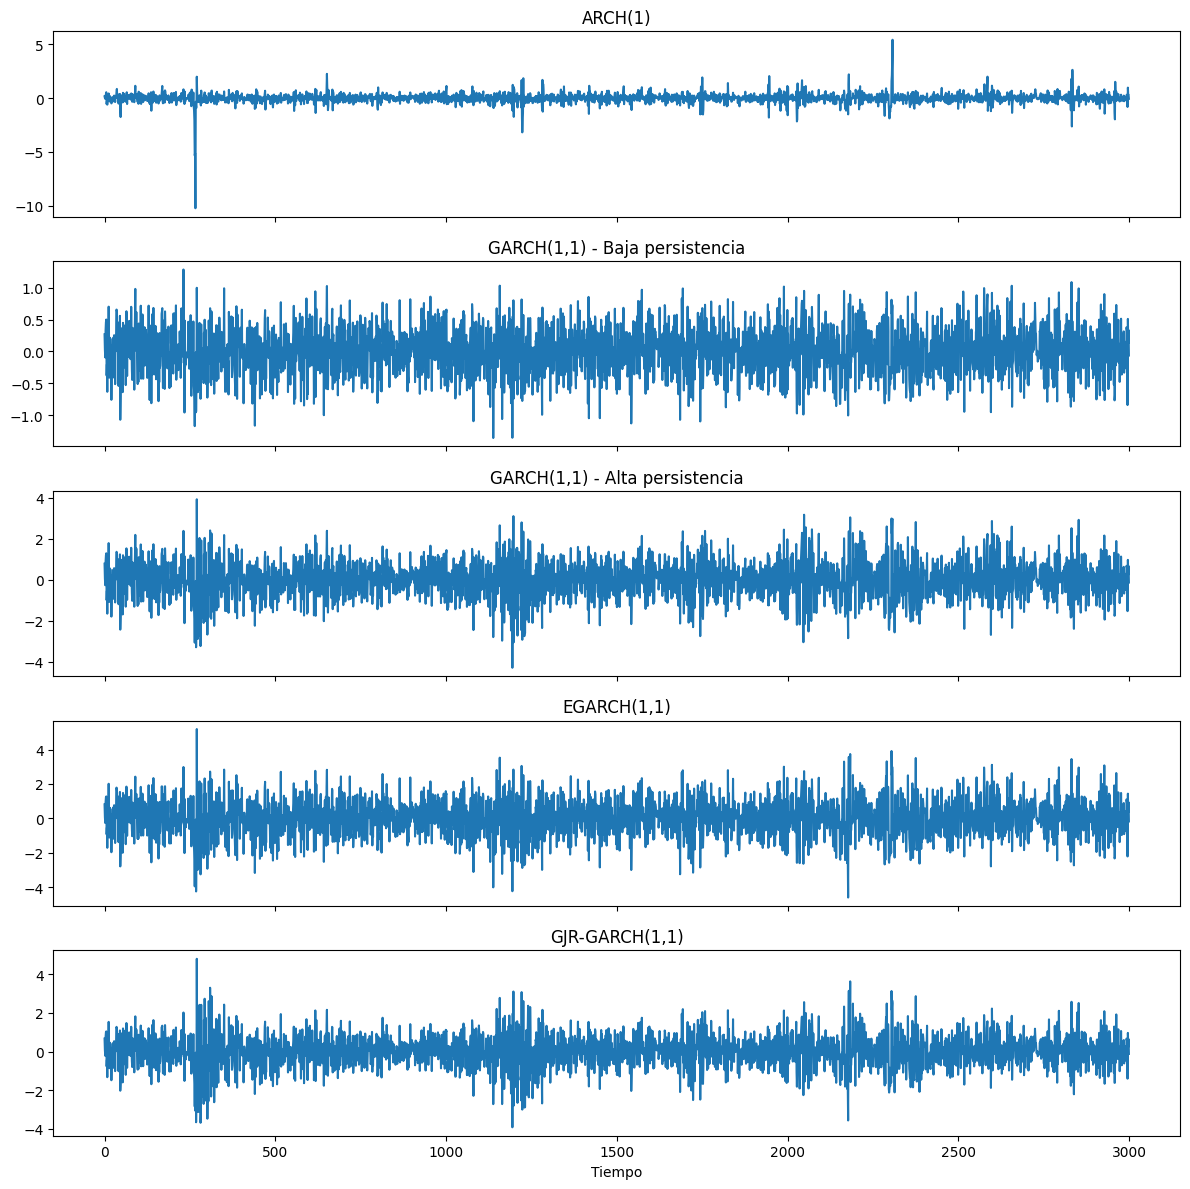

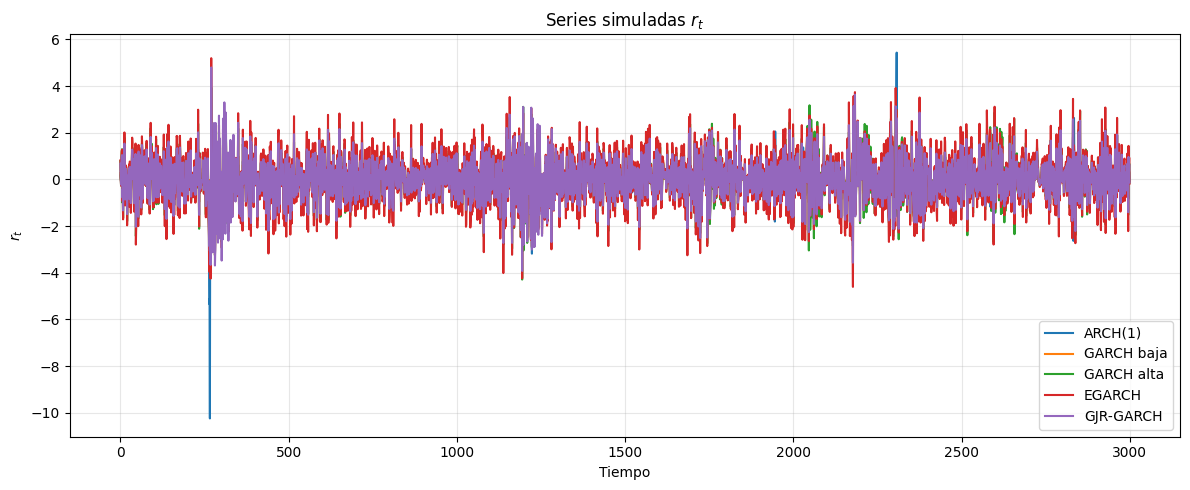

In [38]:
#Gráficos de las series simuladas

fig, ax = plt.subplots(5, 1, figsize=(12,12), sharex=True)

ax[0].plot(r_arch)
ax[0].set_title("ARCH(1)")

ax[1].plot(r_garch1)
ax[1].set_title("GARCH(1,1) - Baja persistencia")

ax[2].plot(r_garch2)
ax[2].set_title("GARCH(1,1) - Alta persistencia")

ax[3].plot(r_egarch)
ax[3].set_title("EGARCH(1,1)")

ax[4].plot(r_gjr)
ax[4].set_title("GJR-GARCH(1,1)")
ax[4].set_xlabel("Tiempo")

plt.tight_layout()
plt.show()

#Gráficos de las series simuladas todas juntas

plt.figure(figsize=(12,5))

plt.plot(r_arch, label="ARCH(1)")
plt.plot(r_garch1, label="GARCH baja")
plt.plot(r_garch2, label="GARCH alta")
plt.plot(r_egarch, label="EGARCH")
plt.plot(r_gjr, label="GJR-GARCH")

plt.title("Series simuladas $r_t$")
plt.xlabel("Tiempo")
plt.ylabel("$r_t$")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**(c)** Para los dos GARCH(1,1) simulados, calcule la varianza muestral de $\epsilon_t^2$ sobre las 2.500 observaciones post *burn-in* y compárela con la varianza incondicional teórica $\omega/(1-\alpha-\beta)$ derivada en 1.1(b). Comente la calidad de la aproximación y cómo cambia si aumenta el número de simulaciones a 50.000.


$begin{aligned}
r_t &= \varepsilon_t, \\
\varepsilon_t &= \sigma_t z_t, \\
\sigma_t^2 &= \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2,\end{aligned}$

la varianza incondicional está dada por

$operatorname{Var}(\varepsilon_t)=\frac{\omega}{1-\alpha-\beta},$

siempre que se cumpla la condición de estacionariedad

$\alpha + \beta < 1.$


In [39]:
# Simulación GARCH(1,1) baja persistencia
r1, sigma1 = simulate_garch(
    T=3000,
    omega=0.05,
    alpha=0.05,
    beta=0.60
)

# Varianza muestral
var_muestral1 = np.var(r1, ddof=1)

# Varianza teórica
var_teorica1 = 0.05/(1-0.05-0.60)

print(f"Varianza muestral : {var_muestral1:.4f}")
print(f"Varianza teórica  : {var_teorica1:.4f}")

Varianza muestral : 0.1351
Varianza teórica  : 0.1429


In [40]:
# Simulación GARCH(1,1) alta persistencia

r2, sigma2 = simulate_garch(
    T=3000,
    omega=0.02,
    alpha=0.08,
    beta=0.90
)

var_muestral2 = np.var(r2, ddof=1)

var_teorica2 = 0.02/(1-0.08-0.90)

print(f"Varianza muestral : {var_muestral2:.4f}")
print(f"Varianza teórica  : {var_teorica2:.4f}")

Varianza muestral : 0.8176
Varianza teórica  : 1.0000


In [41]:
# Simulación GARCH(1,1) baja persistencia 50.000 Observaciones
r1, sigma1 = simulate_garch(
    T=50000,
    omega=0.05,
    alpha=0.05,
    beta=0.60
)

# Varianza muestral
var_muestral1 = np.var(r1, ddof=1)

# Varianza teórica
var_teorica1 = 0.05/(1-0.05-0.60)

print(f"Varianza muestral : {var_muestral1:.4f}")
print(f"Varianza teórica  : {var_teorica1:.4f}")

Varianza muestral : 0.1430
Varianza teórica  : 0.1429


In [42]:
# Simulación GARCH(1,1) alta persistencia 50.000 Observaciones

r2, sigma2 = simulate_garch(
    T=50000,
    omega=0.02,
    alpha=0.08,
    beta=0.90
)

var_muestral2 = np.var(r2, ddof=1)

var_teorica2 = 0.02/(1-0.08-0.90)

print(f"Varianza muestral : {var_muestral2:.4f}")
print(f"Varianza teórica  : {var_teorica2:.4f}")

Varianza muestral : 0.9873
Varianza teórica  : 1.0000


Al aumentar el número de observaciones simuladas a 50.000, la varianza muestral converge hacia la varianza incondicional teórica en ambos modelos, de acuerdo con la Ley de los Grandes Números. La diferencia entre ambas medidas disminuye considerablemente y la aproximación es especialmente notoria en el modelo de alta persistencia, donde se requiere un tamaño muestral mayor para reproducir adecuadamente el comportamiento de largo plazo del proceso.

**(d)** Compare visualmente la asimetría del EGARCH y del GJR-GARCH: simule choques $z_t$ idénticos (misma semilla) para ambos modelos y grafique $\sigma_t$ resultante ante una racha de choques negativos vs. una racha de choques positivos de igual magnitud. ¿Qué modelo reacciona más fuerte a los choques negativos?

In [43]:
# Modelo EGARCH (1,1)

def simulate_egarch_given_z(z, omega, alpha, gamma, beta):

    n = len(z)

    log_sigma2 = np.zeros(n)
    sigma2 = np.zeros(n)

    c = np.sqrt(2/np.pi)

    log_sigma2[0] = omega/(1-beta)
    sigma2[0] = np.exp(log_sigma2[0])

    for t in range(1,n):

        log_sigma2[t] = (omega
                         + beta*log_sigma2[t-1]
                         + alpha*(abs(z[t-1])-c)
                         + gamma*z[t-1])

        sigma2[t] = np.exp(log_sigma2[t])

    return np.sqrt(sigma2)

In [44]:
# Modelo GJR-GARCH (1,1)

def simulate_gjr_given_z(z, omega, alpha, gamma, beta):

    n = len(z)

    sigma2 = np.zeros(n)
    eps = np.zeros(n)

    sigma2[0] = omega/(1-alpha-beta-gamma/2)

    eps[0] = np.sqrt(sigma2[0])*z[0]

    for t in range(1,n):

        indicador = 1 if eps[t-1] < 0 else 0

        sigma2[t] = (omega
                     + alpha*eps[t-1]**2
                     + gamma*indicador*eps[t-1]**2
                     + beta*sigma2[t-1])

        eps[t] = np.sqrt(sigma2[t])*z[t]

    return np.sqrt(sigma2)

In [45]:
# Choques positivos y negativos

#Positivo
T = 200
z_pos = np.ones(T)

#Negativo
z_neg = -np.ones(T)

In [46]:
# Modelo EGARCH (1,1) choques positivos y negativos

sigma_pos_eg = simulate_egarch_given_z(
    z_pos,
    omega=0.01,
    alpha=0.10,
    gamma=-0.08,
    beta=0.95
)

sigma_neg_eg = simulate_egarch_given_z(
    z_neg,
    omega=0.01,
    alpha=0.10,
    gamma=-0.08,
    beta=0.95
)

# Modelo GJR-GARCH (1,1) choques positivos y negativos

sigma_pos_gjr = simulate_gjr_given_z(
    z_pos,
    omega=0.02,
    alpha=0.03,
    gamma=0.09,
    beta=0.90
)

sigma_neg_gjr = simulate_gjr_given_z(
    z_neg,
    omega=0.02,
    alpha=0.03,
    gamma=0.09,
    beta=0.90
)

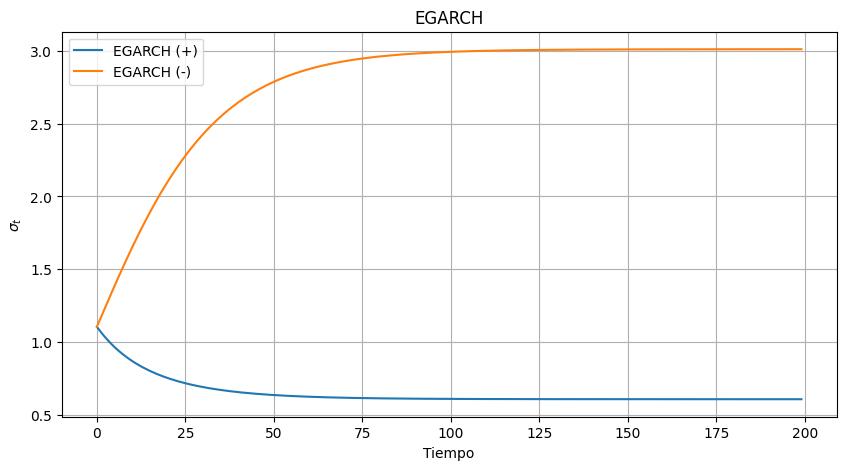

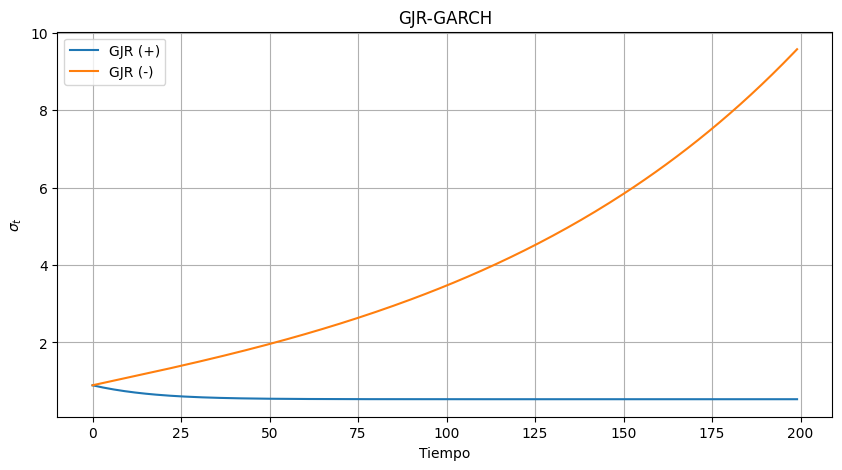

In [47]:
#Gráficos de las series simuladas para choques positivos y negativos
plt.figure(figsize=(10,5))

plt.plot(sigma_pos_eg, label="EGARCH (+)")
plt.plot(sigma_neg_eg, label="EGARCH (-)")

plt.title("EGARCH")
plt.ylabel(r"$\sigma_t$")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True)

plt.figure(figsize=(10,5))

plt.plot(sigma_pos_gjr, label="GJR (+)")
plt.plot(sigma_neg_gjr, label="GJR (-)")

plt.title("GJR-GARCH")
plt.ylabel(r"$\sigma_t$")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True)

plt.show()

Se utilizaron choques estandarizados idénticos para ambos modelos, considerando una secuencia de choques positivos $z_t = 1$ y otra de igual magnitud pero negativos $z_t = -1$. Esto permite aislar el efecto de la asimetría incorporada en cada especificación.

En el modelo **EGARCH**, la asimetría proviene del término $\gamma z_{t-1}$. Dado que $\gamma = -0.08$, los choques negativos generan un incremento mayor en la volatilidad condicional que los choques positivos de igual magnitud. La respuesta es continua, ya que depende directamente del signo y del tamaño del choque.

En el modelo **GJR-GARCH**, la asimetría se introduce mediante el término $\gamma I(\varepsilon_{t-1}<0)\varepsilon_{t-1}^{2}$. Cuando el choque es negativo, el indicador toma valor uno y se añade un componente adicional a la varianza condicional; para choques positivos, dicho término es cero. Esto produce un aumento más pronunciado de la volatilidad frente a choques negativos.

En las simulaciones se observa que ambos modelos reproducen el **efecto de apalancamiento** (*leverage effect*), pero el **GJR-GARCH** presenta una reacción más intensa frente a una racha de choques negativos, mientras que el **EGARCH** genera una respuesta asimétrica más gradual. Por lo tanto, para los parámetros utilizados, el **GJR-GARCH** reacciona más fuertemente a los choques negativos.
